<a href="https://colab.research.google.com/github/georgerieh/ml-ai-code-studies/blob/main/clothes-classifier-CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [93]:
import os
import pandas as pd
from torchvision.io import decode_image
from torch.utils.data import Dataset, random_split, Subset
import torch
class_dict = {
    '1':'upper-body clothes',
    '2':'lower-body clothes',
    '3':'full-body clothes'
}
def get_class_name(c_id):
    return class_dict[str(c_id)]

transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((128, 128)),
    transforms.Grayscale(num_output_channels=1), # Converts to Grayscale
    transforms.ToTensor(),                       # [0, 255] -> [0, 1]
    transforms.Normalize((0.5,), (0.5,))         # [0, 1] -> [-1, 1]
])


class FashionDataset(Dataset):
    def __init__(self, img_dir, annotations_file, transform=transform, target_transform=None):
        self.img_labels = pd.read_csv(annotations_file, sep=r'\s+', skiprows=1)

        self.img_dir = img_dir
        self.transform = transform
        self.target_transform = target_transform

    def __len__(self):
        return len(self.img_labels)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.img_labels.iloc[idx, 0])
        image = decode_image(img_path)
        label = self.img_labels.iloc[idx, 1]
        if self.transform:
            image = self.transform(image)
        if self.target_transform:
            label = self.target_transform(label)
        return image, label






In [7]:
!unzip -q '/content/drive/MyDrive/fashion/Копия img.zip' -d 'img'

In [8]:
!cp '/content/drive/MyDrive/fashion/Копия list_landmarks.txt' 'list_landmarks.txt'

In [65]:

dataset = FashionDataset("img/", "list_landmarks.txt", transform=transform)

num_samples = 7000
indices = np.random.choice(len(dataset), num_samples, replace=False)



small_subset = Subset(dataset, indices)

train_size = int(0.8 * num_samples)
test_size = num_samples - train_size


train_dataset, test_dataset = random_split(small_subset, [train_size, test_size])

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=32, shuffle=False)






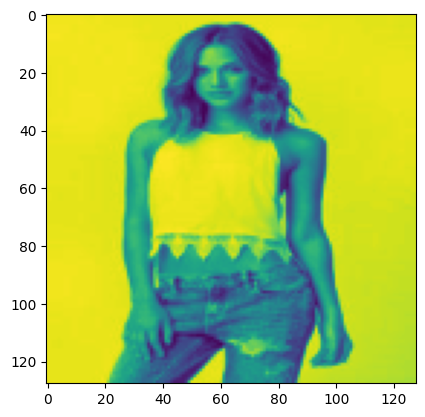

Label: upper-body clothes


In [66]:
train_features, train_labels = next(iter(train_dataloader))
img = train_features[0].squeeze()
label = train_labels[0]
plt.imshow(img)
plt.show()
print(f"Label: {get_class_name(label.item())}")

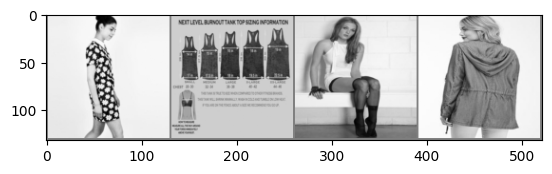

full-body clothes||upper-body clothes||upper-body clothes||upper-body clothes


In [67]:
import matplotlib.pyplot as plt
import numpy as np

# functions to show an image


def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()

    # If the image is grayscale (1 channel), squeeze it to (256, 256)
    if npimg.shape[0] == 1:
        plt.imshow(npimg[0], cmap='gray')
    else:
        plt.imshow(np.transpose(npimg, (1, 2, 0)))

    plt.show()


# get some random training images
dataiter = iter(train_dataloader)
images, labels = next(dataiter)
# show images
imshow(torchvision.utils.make_grid(images))
# print labels
print('||'.join(f'{get_class_name(labels[j].item()):5s}' for j in range(4)))

In [68]:
import torch.nn as nn
import torch.nn.functional as F


class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        # Calculate the correct input when input is 256x256 features for fc1 based on image size 256x256
        # Output size after conv1: (256 - 5 + 1) = 252
        # Output size after pool1: 252 / 2 = 126
        # Output size after conv2: (126 - 5 + 1) = 122
        # Output size after pool2: 122 / 2 = 61
        # So, the flattened size is 16 * 61 * 61
        self.fc1 = nn.Linear(16 * 29 * 29, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1) # flatten all dimensions except batch
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)

        return x


net = Net()

In [69]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)

In [71]:
from tqdm import tqdm
for epoch in range(2):  # loop over the dataset multiple times

    running_loss = 0.0
    for i, data in enumerate(tqdm(train_loader), 0):
        # get the inputs; data is a list of [inputs, labels]
        inputs, labels = data

        # zero the parameter gradients
        optimizer.zero_grad()

        # forward + backward + optimize
        outputs = net(inputs)
        labels = torch.stack(list(labels), dim=0)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # print statistics
        running_loss += loss.item()
        if i % 2000 == 1999:    # print every 2000 mini-batches
            print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / 2000:.3f}')
            running_loss = 0.0

print('Finished Training')


100%|██████████| 175/175 [00:36<00:00,  4.83it/s]

Finished Training


In [75]:
PATH = './model_not_bbox_net.pth'
torch.save(net.state_dict(), PATH)

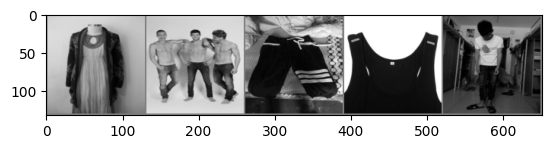

GroundTruth:  upper-body clothes||lower-body clothes||lower-body clothes||upper-body clothes||upper-body clothes


In [80]:
dataiter = iter(test_loader)
images, labels = next(dataiter)
ims, lbs = images[:5], labels[:5]

# print images
imshow(torchvision.utils.make_grid(ims))
print('GroundTruth: ', '||'.join(f'{get_class_name(lbs[j].item()):5s}' for j in range(5)))

In [81]:
net = Net()
net.load_state_dict(torch.load(PATH, weights_only=True))

<All keys matched successfully>

In [83]:
outputs = net(ims)

In [86]:
_, predicted = torch.max(outputs, 1)

print('Predicted: ', '||'.join(f'{get_class_name(predicted[j].item()):5s}'
                              for j in range(5)))

Predicted:  upper-body clothes||full-body clothes||full-body clothes||full-body clothes||full-body clothes


In [89]:
correct = 0
total = 0
# since we're not training, we don't need to calculate the gradients for our outputs
with torch.no_grad():
    for data in test_loader:
        images, labels = data
        # calculate outputs by running images through the network
        outputs = net(images)
        # the class with the highest energy is what we choose as prediction
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Accuracy of the network on the {total} test images: {100 * correct // total} %')

Accuracy of the network on the 1400 test images: 44 %
